## Hierarchical Diabetes Classification Model
This notebook implements a two-stage hierarchical classification:
1. **Stage 1**: Binary classification (Diabetes vs No Diabetes)
2. **Stage 2**: For diabetes cases, classify (Prediabetes vs Diabetes)

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
)
from xgboost import XGBClassifier

# Feature selection
from scipy.stats import spearmanr

# Save models
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Data Acquisition

In [ ]:
df = pd.read_csv("balanced_diabetes_data.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (641109, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_012
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,0.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,0.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,0.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,0.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641109 entries, 0 to 641108
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HighBP                641109 non-null  float64
 1   HighChol              641109 non-null  float64
 2   CholCheck             641109 non-null  float64
 3   BMI                   641109 non-null  float64
 4   Smoker                641109 non-null  float64
 5   Stroke                641109 non-null  float64
 6   HeartDiseaseorAttack  641109 non-null  float64
 7   PhysActivity          641109 non-null  float64
 8   Fruits                641109 non-null  float64
 9   Veggies               641109 non-null  float64
 10  HvyAlcoholConsump     641109 non-null  float64
 11  AnyHealthcare         641109 non-null  float64
 12  NoDocbcCost           641109 non-null  float64
 13  GenHlth               641109 non-null  float64
 14  MentHlth              641109 non-null  float64
 15  

## Data Cleaning
### Checking for null values

In [ ]:
print("Initial shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())

Initial shape: (641109, 22)
Total missing values: 0


### Checking for duplicate rows

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df_clean = df.drop_duplicates()
print("Final shape after cleaning:", df_clean.shape)

Duplicate rows: 24515
Final shape after cleaning: (616594, 22)


## Feature Selection

In [ ]:
# Define initial feature pool
all_features = [col for col in df_clean.columns if col != 'Diabetes_012']

print(f"Total available features: {len(all_features)}")
print(f"Features: {all_features}")

Total available features: 21
Features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


### Correlation Analysis

In [ ]:
# Calculate correlation with target variable
X_all = df_clean[all_features]
y_target = df_clean['Diabetes_012']

correlations = {}
for feature in all_features:
    # Spearman correlation method
    corr, p_value = spearmanr(X_all[feature], y_target)
    correlations[feature] = {'correlation': abs(corr), 'p_value': p_value}

# Create DataFrame for analysis
corr_df = pd.DataFrame(correlations).T
corr_df = corr_df.sort_values('correlation', ascending=True)

print("Feature Correlation")
print("===================")
print(corr_df)

Feature Correlation
                      correlation        p_value
AnyHealthcare            0.009365   1.929095e-13
MentHlth                 0.022636   1.069045e-70
Fruits                   0.037832  4.589687e-194
Sex                      0.047775  2.373957e-308
NoDocbcCost              0.048207   0.000000e+00
Smoker                   0.058832   0.000000e+00
HvyAlcoholConsump        0.068974   0.000000e+00
Veggies                  0.073453   0.000000e+00
CholCheck                0.098129   0.000000e+00
Education                0.117773   0.000000e+00
Stroke                   0.125392   0.000000e+00
PhysActivity             0.135953   0.000000e+00
PhysHlth                 0.152720   0.000000e+00
Income                   0.158728   0.000000e+00
Age                      0.200293   0.000000e+00
HeartDiseaseorAttack     0.203668   0.000000e+00
DiffWalk                 0.237971   0.000000e+00
HighChol                 0.243715   0.000000e+00
BMI                      0.247951   0.000000e+00


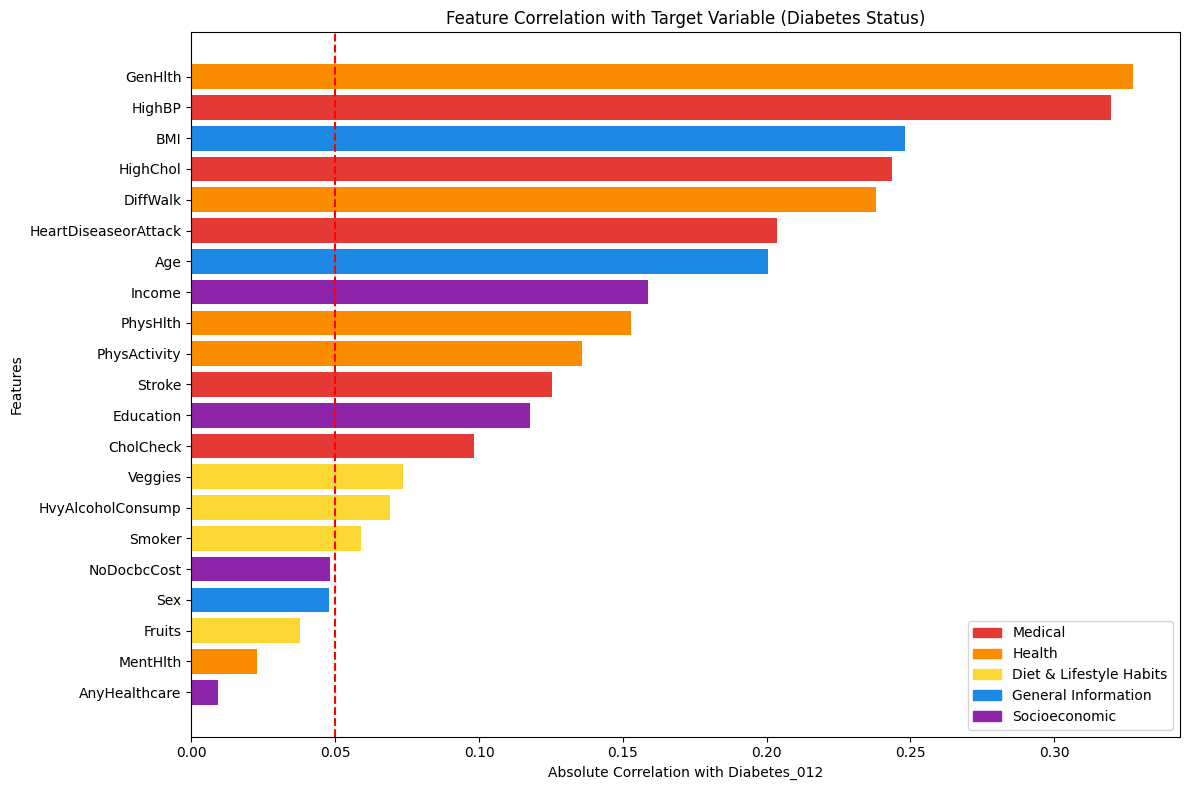

In [ ]:
# group features into categories
feature_colors = {
    # medical
    'HighBP': '#e53935', 'HighChol': '#e53935', 'CholCheck': '#e53935', 
    'Stroke': '#e53935', 'HeartDiseaseorAttack': '#e53935',
    
    # health
    'PhysActivity': '#fb8c00', 'GenHlth': '#fb8c00', 
    'PhysHlth': '#fb8c00', 'MentHlth': '#fb8c00', 'DiffWalk': '#fb8c00',
    
    # lifestyle habits
    'Smoker': '#fdd835', 'HvyAlcoholConsump': '#fdd835', 
    'Fruits': '#fdd835', 'Veggies': '#fdd835',
    
    # general info (Blue)
    'Age': '#1e88e5', 'Sex': '#1e88e5', 'BMI': '#1e88e5',
    
    # socioeconomic
    'Income': '#8e24aa', 'Education': '#8e24aa',
    'AnyHealthcare': '#8e24aa', 'NoDocbcCost': '#8e24aa'
}

# Get colors for each feature in sorted order
colors = [feature_colors.get(feat, '#424242') for feat in corr_df.index] 

plt.figure(figsize=(12, 8))
plt.barh(corr_df.index, corr_df['correlation'], color=colors)
plt.xlabel('Absolute Correlation with Diabetes_012')
plt.ylabel('Features')
plt.title('Feature Correlation with Target Variable (Diabetes Status)')
plt.axvline(x=0.05, color='r', linestyle='--', label='Threshold (0.05)')

# legend
legend_elements = [
    mpatches.Patch(color='#e53935', label='Medical'),
    mpatches.Patch(color='#fb8c00', label='Health'),
    mpatches.Patch(color='#fdd835', label='Diet & Lifestyle Habits'),
    mpatches.Patch(color='#1e88e5', label='General Information'),
    mpatches.Patch(color='#8e24aa', label='Socioeconomic')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
CORRELATION_THRESHOLD = 0.05  # Features with |correlation| < 0.05 are weak

weak_features = corr_df[corr_df['correlation'] < CORRELATION_THRESHOLD].index.tolist()
strong_features = corr_df[corr_df['correlation'] >= CORRELATION_THRESHOLD].index.tolist()

print(f"\n📊 Correlation Analysis Results:")
print(f"  Strong features (|r| >= {CORRELATION_THRESHOLD}): {len(strong_features)}")
print(f"  Weak features (|r| < {CORRELATION_THRESHOLD}): {len(weak_features)}")
print(f"\nWeak features to consider removing:")
for feat in weak_features:
    print(f"  - {feat}: r = {corr_df.loc[feat, 'correlation']:.4f}")


📊 Correlation Analysis Results:
  Strong features (|r| >= 0.05): 16
  Weak features (|r| < 0.05): 5

Weak features to consider removing:
  - AnyHealthcare: r = 0.0094
  - MentHlth: r = 0.0226
  - Fruits: r = 0.0378
  - Sex: r = 0.0478
  - NoDocbcCost: r = 0.0482


##### features which were removed:
- AnyHealthcare
- MentHlth
- NoDocbcCost
- Income
- Education

In [ ]:
clinical_features = [ 
    'BMI', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'GenHlth', 'PhysHlth',
    'DiffWalk', 'Sex', 'Age', 'HighBP', 'HighChol', 
    'CholCheck', 'Stroke', 'HeartDiseaseorAttack'
]

non_clinical_features = [
    'BMI', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'GenHlth', 'PhysHlth',
    'DiffWalk', 'Sex', 'Age'
]

print("Number of clinical features:", len(clinical_features))
print("Number of non-clinical features:", len(non_clinical_features))

Number of clinical features: 16
Number of non-clinical features: 11


In [ ]:
# feature engineering to help distinguish prediabetes from diabetes
def create_engineered_features(X):
    X_eng = X.copy()
    
    # BMI-based interactions
    X_eng['BMI_Age'] = X_eng['BMI'] * X_eng['Age']
    X_eng['BMI_GenHlth'] = X_eng['BMI'] * X_eng['GenHlth']
    X_eng['BMI_squared'] = X_eng['BMI'] ** 2
    
    # Health status combinations
    X_eng['Poor_Health_Score'] = (
        X_eng['GenHlth'] * 2 + 
        X_eng['PhysHlth'] / 10
    )
    
    # Lifestyle score
    X_eng['HealthyLifestyle'] = (
        X_eng['PhysActivity'] + 
        X_eng['Fruits'] + 
        X_eng['Veggies'] - 
        X_eng['Smoker'] - 
        X_eng['HvyAlcoholConsump']
    )
    
    # Age-based interactions
    X_eng['Age_GenHlth'] = X_eng['Age'] * X_eng['GenHlth']
    X_eng['Age_PhysHlth'] = X_eng['Age'] * (X_eng['PhysHlth'] / 30)
    
    # Mobility score
    X_eng['Mobility_Score'] = X_eng['DiffWalk'] * X_eng['PhysHlth']

    # Risk score combinations
    if 'HighBP' in X_eng.columns:
        X_eng['Total_Risk_Score'] = (
            X_eng['HighBP'] + X_eng['HighChol'] + 
            X_eng['Stroke'] + X_eng['HeartDiseaseorAttack']
        )
        
        # Metabolic syndrome proxy
        X_eng['MetabolicSyndrome_Proxy'] = (
            (X_eng['BMI'] > 30).astype(int) + 
            X_eng['HighBP'] + 
            X_eng['HighChol']
        )
    
    # Health deterioration indicators (transition markers)
    X_eng['Health_Decline'] = X_eng['GenHlth'] * (1 + X_eng['PhysHlth']/30)
    
    # Age-risk interactions (prediabetes often occurs in younger ages)
    X_eng['Age_BMI_Risk'] = X_eng['Age'] * X_eng['BMI'] / 100
    X_eng['Young_High_BMI'] = ((X_eng['Age'] < 7) & (X_eng['BMI'] > 30)).astype(int)
    
    # Lifestyle factors
    X_eng['Lifestyle_Risk'] = (
        (1 - X_eng['PhysActivity']) + 
        (1 - X_eng['Fruits']) + 
        (1 - X_eng['Veggies']) + 
        X_eng['Smoker'] + 
        X_eng['HvyAlcoholConsump']
    )
    
    return X_eng

In [ ]:
# Extract features from cleaned data
X_clinical_raw = df_clean[clinical_features]
X_non_clinical_raw = df_clean[non_clinical_features]

# Apply feature engineering
X_clinical = create_engineered_features(X_clinical_raw)
X_non_clinical = create_engineered_features(X_non_clinical_raw)
y = df_clean['Diabetes_012']

# Update feature lists
clinical_features_eng = X_clinical.columns.tolist()
non_clinical_features_eng = X_non_clinical.columns.tolist()

print(f"\nFeatures prepared:")
print(f"  Clinical: {len(clinical_features)} raw → {len(clinical_features_eng)} engineered")
print(f"  Non-clinical: {len(non_clinical_features)} raw → {len(non_clinical_features_eng)} engineered")

# Display engineered feature names
print(f"\nClinical engineered features:")
print(clinical_features_eng)


Features prepared:
  Clinical: 16 raw → 30 engineered
  Non-clinical: 11 raw → 23 engineered

Clinical engineered features:
['BMI', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'GenHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'HighBP', 'HighChol', 'CholCheck', 'Stroke', 'HeartDiseaseorAttack', 'BMI_Age', 'BMI_GenHlth', 'BMI_squared', 'Poor_Health_Score', 'HealthyLifestyle', 'Age_GenHlth', 'Age_PhysHlth', 'Mobility_Score', 'Total_Risk_Score', 'MetabolicSyndrome_Proxy', 'Health_Decline', 'Age_BMI_Risk', 'Young_High_BMI', 'Lifestyle_Risk']


## Hierarchical Data Preparation
This dataset will be seperated into two:
1. **Stage 1**: Binary classification - No Diabetes (0) vs Any Diabetes (1 or 2)
2. **Stage 2**: Only diabetes cases - Prediabetes (1) vs Diabetes (2)

In [ ]:
# Stage 1: Binary classification (0 vs 1+2)
y_stage1 = (y > 0).astype(int)
print("Stage 1: Binary Classification:")
print(y_stage1.value_counts().sort_index())

print("===============================================\n")

# Stage 2: Prediabetes vs. Diabetes (1 vs 2)
diabetes_mask = y > 0
X_clinical_stage2 = X_clinical[diabetes_mask]
X_non_clinical_stage2 = X_non_clinical[diabetes_mask]
y_stage2_original = y[diabetes_mask]

# Remap labels for binary classification (1-->0, 2-->1)
y_stage2 = (y_stage2_original == 2).astype(int)

print("Stage 2: Prediabetes vs Diabetes:")
print("After remapping (0=Prediabetes, 1=Diabetes):")
print(y_stage2.value_counts().sort_index())
print(f"Total diabetes cases: {len(y_stage2)}")

Stage 1: Binary Classification:
Diabetes_012
0    190055
1    426539
Name: count, dtype: int64

Stage 2: Prediabetes vs Diabetes:
After remapping (0=Prediabetes, 1=Diabetes):
Diabetes_012
0    213668
1    212871
Name: count, dtype: int64
Total diabetes cases: 426539


## Data Splitting 
Data will be split into 80% training and 20% testing as the dataset is relatively large and does not need much data to be allocated for testing

### *Stage 1: Binary Classification*

In [ ]:
# stage 1 - clinical
Xc_train_s1, Xc_test_s1, yc_train_s1, yc_test_s1 = train_test_split(
    X_clinical, y_stage1,
    test_size=0.2,
    random_state=42,
    stratify=y_stage1
)

# stage 1 - non clinical
Xn_train_s1, Xn_test_s1, yn_train_s1, yn_test_s1 = train_test_split(
    X_non_clinical, y_stage1,
    test_size=0.2,
    random_state=42,
    stratify=y_stage1
)

print("Stage 1:\nTraining set size:", Xc_train_s1.shape)
print("Testing set size:", Xc_test_s1.shape)

Stage 1:
Training set size: (493275, 30)
Testing set size: (123319, 30)


### *Stage 2: Prediabetes vs. Diabetes split*

In [ ]:
# stage 2 - Clinical features
Xc_train_s2, Xc_test_s2, yc_train_s2, yc_test_s2 = train_test_split(
    X_clinical_stage2, y_stage2,
    test_size=0.2,
    random_state=42,
    stratify=y_stage2
)

# Stage 2 - Non-clinical features
Xn_train_s2, Xn_test_s2, yn_train_s2, yn_test_s2 = train_test_split(
    X_non_clinical_stage2, y_stage2,
    test_size=0.2,
    random_state=42,
    stratify=y_stage2
)

print("Stage 2:\nTraining set size:", Xc_train_s2.shape)
print("Testing set size:", Xc_test_s2.shape)

Stage 2:
Training set size: (341231, 30)
Testing set size: (85308, 30)


### Handling outliers (IQR Method)

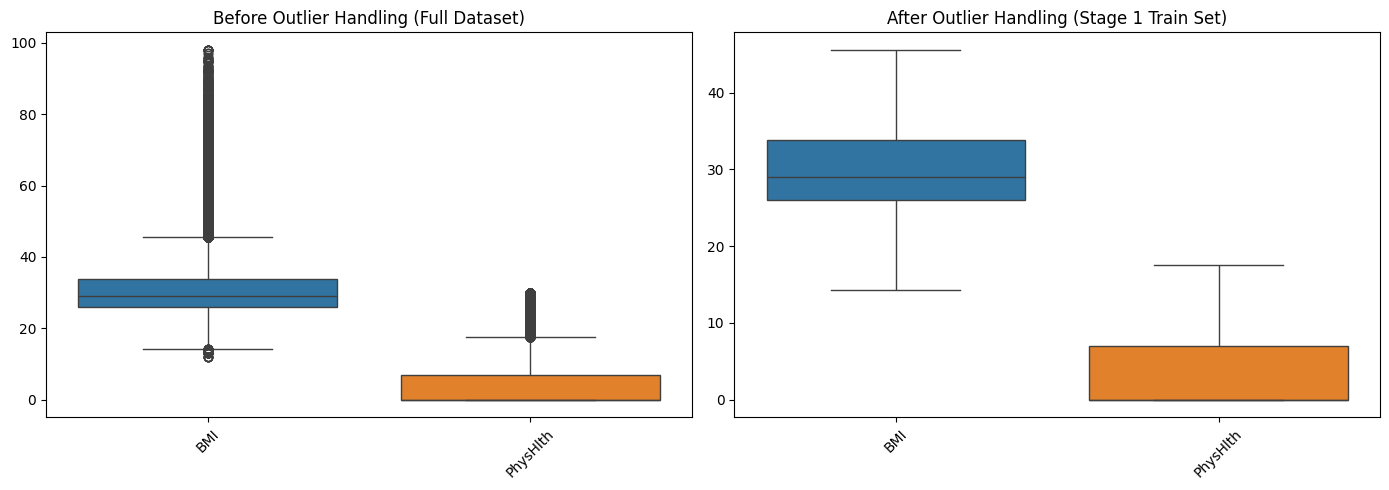

In [ ]:
# Continuous features only
num_features = ['BMI', 'PhysHlth']

def clip_outliers_iqr(df, features):
    df = df.copy()
    for col in features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = np.clip(df[col], lower_bound, upper_bound)
    return df

# Visualize before and after outlier handling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
sns.boxplot(data=X_clinical[num_features], ax=axes[0])
axes[0].set_title("Before Outlier Handling (Full Dataset)")
axes[0].tick_params(axis='x', rotation=45)

# After (on Stage 1 training set)
Xc_train_s1_clipped = clip_outliers_iqr(Xc_train_s1, num_features)
sns.boxplot(data=Xc_train_s1_clipped[num_features], ax=axes[1])
axes[1].set_title("After Outlier Handling (Stage 1 Train Set)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Apply outlier clipping to all training sets
# Stage 1
Xc_train_s1 = clip_outliers_iqr(Xc_train_s1, num_features)
Xn_train_s1 = clip_outliers_iqr(Xn_train_s1, num_features)

# Stage 2
Xc_train_s2 = clip_outliers_iqr(Xc_train_s2, num_features)
Xn_train_s2 = clip_outliers_iqr(Xn_train_s2, num_features)

## Model Training
### *Stage 1 Training*

In [ ]:
# XGBoost - Stage 1 Clinical
xgb_stage1_clinical = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    learning_rate=0.01,
    n_estimators=2500,
    max_depth=10,
    min_child_weight=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.01,
    reg_lambda=0.2,
    gamma=0.1,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

xgb_stage1_clinical.fit(Xc_train_s1, yc_train_s1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=0.03, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
# XGBoost - Stage 1 Non-Clinical
xgb_stage1_non_clinical = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    learning_rate=0.01,
    n_estimators=2500,
    max_depth=10,
    min_child_weight=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.01,
    reg_lambda=0.2,
    gamma=0.1,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

xgb_stage1_non_clinical.fit(Xn_train_s1, yn_train_s1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=0.03, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2500, n_jobs=-1,
              num_parallel_tree=None, ...)

### *Stage 2 Traning*

In [ ]:
# XGBoost - Stage 2 Clinical
xgb_stage2_clinical = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    learning_rate=0.01,
    n_estimators=2500,
    max_depth=10,
    min_child_weight=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.01,
    reg_lambda=0.2,
    gamma=0.1,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

xgb_stage2_clinical.fit(Xc_train_s2, yc_train_s2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=0.03, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
# XGBoost - Stage 2 Non-Clinical
xgb_stage2_non_clinical = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    learning_rate=0.01,
    n_estimators=2500,
    max_depth=10,
    min_child_weight=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.01,
    reg_lambda=0.2,
    gamma=0.1,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

xgb_stage2_non_clinical.fit(Xn_train_s2, yn_train_s2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=0.03, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2500, n_jobs=-1,
              num_parallel_tree=None, ...)

### Save models

In [ ]:
# Stage 1
joblib.dump(xgb_stage1_clinical, "xgb_stage1_clinical.pkl")
joblib.dump(xgb_stage1_non_clinical, "xgb_stage1_non_clinical.pkl")

# Stage 2
joblib.dump(xgb_stage2_clinical, "xgb_stage2_clinical.pkl")
joblib.dump(xgb_stage2_non_clinical, "xgb_stage2_non_clinical.pkl")

['xgb_stage2_non_clinical.pkl']

## Model Evaluation

In [ ]:
def evaluate_binary_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    
    print(title)
    print("=" * 60)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1-Score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-Score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return y_pred

In [ ]:
def hierarchical_predict(model_s1, model_s2, X_test, threshold_s1=0.3, threshold_s2=0.6):
    # Stage 1: Predict diabetes vs no diabetes
    stage1_proba = model_s1.predict_proba(X_test)[:, 1]
    stage1_pred = (stage1_proba >= threshold_s1).astype(int)
    
    final_pred = np.zeros(len(X_test), dtype=int)
    diabetes_mask = stage1_pred == 1
    
    if diabetes_mask.sum() > 0:
        X_diabetes = X_test[diabetes_mask]
        
        # Stage 2: Predict prediabetes vs diabetes
        stage2_proba = model_s2.predict_proba(X_diabetes)[:, 1]
        stage2_pred = (stage2_proba >= threshold_s2).astype(int)
        
        # Remap: 0→1 (prediabetes), 1→2 (diabetes)
        stage2_pred_remapped = stage2_pred + 1
        final_pred[diabetes_mask] = stage2_pred_remapped
    
    return final_pred

In [ ]:
def evaluate_hierarchical_model(model_s1, model_s2, X_test, y_test, title):
    y_pred = hierarchical_predict(model_s1, model_s2, X_test)
    
    print(title)
    print("=" * 60)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1-Score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-Score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=['No Diabetes', 'Prediabetes', 'Diabetes']))
    
    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
                xticklabels=['No Diabetes', 'Prediabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Prediabetes', 'Diabetes'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    return y_pred

## *Stage 1 Evaluation*


============STAGE 1: BINARY CLASSIFICATION============

Stage 1: XGBoost Clinical (No Diabetes vs Has Diabetes)
Accuracy: 0.9352
F1-Score (macro): 0.9264
F1-Score (weighted): 0.9362

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90     38011
           1       0.98      0.92      0.95     85308

    accuracy                           0.94    123319
   macro avg       0.92      0.94      0.93    123319
weighted avg       0.94      0.94      0.94    123319



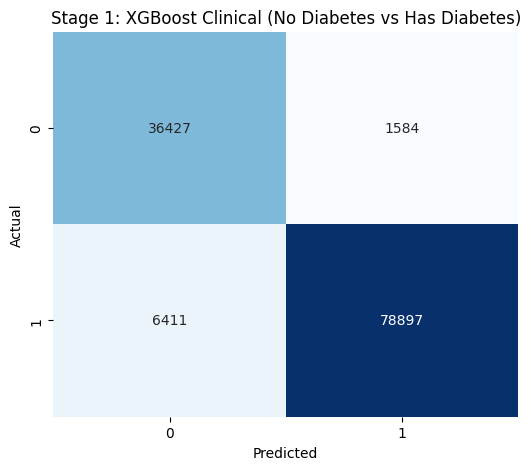

array([1, 1, 1, ..., 1, 0, 0])

In [ ]:
print("\n============STAGE 1: BINARY CLASSIFICATION============\n")
# Evaluate Stage 1 - Clinical
evaluate_binary_model(xgb_stage1_clinical, Xc_test_s1, yc_test_s1, 
                     "Stage 1: XGBoost Clinical (No Diabetes vs Has Diabetes)")

Stage 1: XGBoost Non-Clinical (No Diabetes vs Has Diabetes)
Accuracy: 0.9249
F1-Score (macro): 0.9153
F1-Score (weighted): 0.9262

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.95      0.89     38011
           1       0.98      0.91      0.94     85308

    accuracy                           0.92    123319
   macro avg       0.90      0.93      0.92    123319
weighted avg       0.93      0.92      0.93    123319



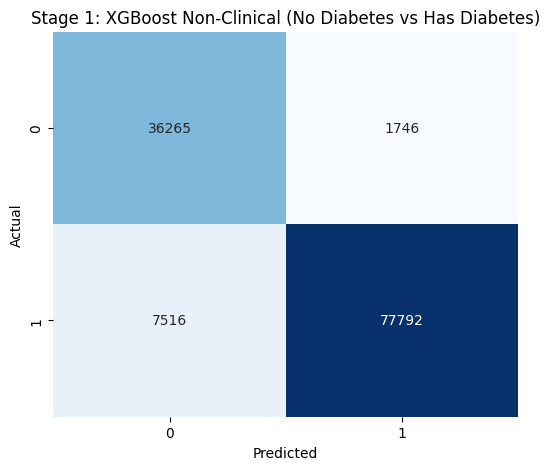

array([1, 1, 1, ..., 1, 0, 0])

In [ ]:
# Evaluate Stage 1 - Non-Clinical
evaluate_binary_model(xgb_stage1_non_clinical, Xn_test_s1, yn_test_s1,
                     "Stage 1: XGBoost Non-Clinical (No Diabetes vs Has Diabetes)")

### Testing Different Classification Thresholds for Stage 1

In [ ]:
# evaluations with thresholds
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.5]

print("=" * 70)
print("TESTING DIFFERENT CLASSIFICATION THRESHOLDS FOR STAGE 1 (CLINICAL)")
print("=" * 70)
print(f"{'Threshold':<12} {'Recall_0':<12} {'Recall_1':<12} {'Precision_1':<12} {'F1_1':<12}")
print("-" * 70)

best_recall_1 = 0
best_threshold = 0.5

for threshold in thresholds:
    # Predict on Stage 1 test set with custom threshold
    stage1_proba = xgb_stage1_clinical.predict_proba(Xc_test_s1)[:, 1]
    stage1_pred = (stage1_proba >= threshold).astype(int)
    
    # Calculate metrics
    recall_0 = recall_score(yc_test_s1, stage1_pred, pos_label=0)
    recall_1 = recall_score(yc_test_s1, stage1_pred, pos_label=1)
    precision_1 = precision_score(yc_test_s1, stage1_pred, pos_label=1, zero_division=0)
    f1_1 = f1_score(yc_test_s1, stage1_pred, pos_label=1)
    
    print(f"{threshold:<12.2f} {recall_0:<12.3f} {recall_1:<12.3f} {precision_1:<12.3f} {f1_1:<12.3f}")
    
    # Track best threshold (prioritizing recall for diabetes detection)
    if recall_1 > best_recall_1:
        best_recall_1 = recall_1
        best_threshold = threshold

print("-" * 70)
print(f"\nRecommended threshold: {best_threshold} (Recall for Has Diabetes: {best_recall_1:.3f})")
print("\nNote: Lower threshold = catch more diabetes cases (higher recall)")
print("      Higher threshold = fewer false alarms (higher precision)")

TESTING DIFFERENT CLASSIFICATION THRESHOLDS FOR STAGE 1 (CLINICAL)
Threshold    Recall_0     Recall_1     Precision_1  F1_1        
----------------------------------------------------------------------
0.20         0.723        0.974        0.888        0.929       
0.25         0.789        0.966        0.911        0.938       
0.30         0.840        0.957        0.931        0.944       
0.35         0.879        0.949        0.946        0.947       
0.40         0.914        0.940        0.961        0.950       
0.50         0.958        0.925        0.980        0.952       
----------------------------------------------------------------------

Recommended threshold: 0.2 (Recall for Has Diabetes: 0.974)

Note: Lower threshold = catch more diabetes cases (higher recall)
      Higher threshold = fewer false alarms (higher precision)


## *Stage 2 Evaluation*

\=======================STAGE 2: PREDIABETES VS DIABETES=======================

Stage 2: XGBoost Clinical (Prediabetes vs Diabetes)
Accuracy: 0.9354
F1-Score (macro): 0.9353
F1-Score (weighted): 0.9353

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94     42734
           1       0.96      0.91      0.93     42574

    accuracy                           0.94     85308
   macro avg       0.94      0.94      0.94     85308
weighted avg       0.94      0.94      0.94     85308



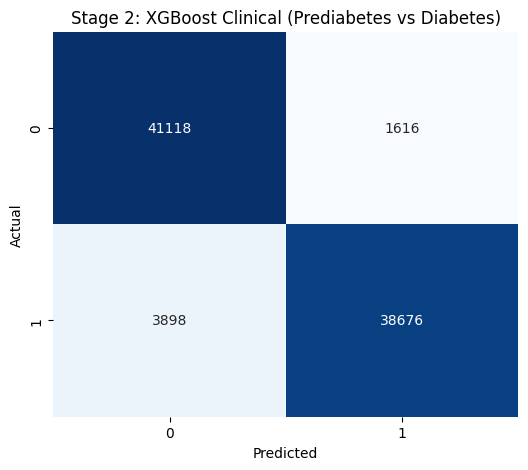

array([0, 0, 1, ..., 0, 1, 1])

In [ ]:
# Evaluate Stage 2 - Clinical``
print("\=======================STAGE 2: PREDIABETES VS DIABETES=======================\n")
evaluate_binary_model(xgb_stage2_clinical, Xc_test_s2, yc_test_s2,
                     "Stage 2: XGBoost Clinical (Prediabetes vs Diabetes)")

Stage 2: XGBoost Non-Clinical (Prediabetes vs Diabetes)
Accuracy: 0.9086
F1-Score (macro): 0.9085
F1-Score (weighted): 0.9085

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     42734
           1       0.94      0.87      0.91     42574

    accuracy                           0.91     85308
   macro avg       0.91      0.91      0.91     85308
weighted avg       0.91      0.91      0.91     85308



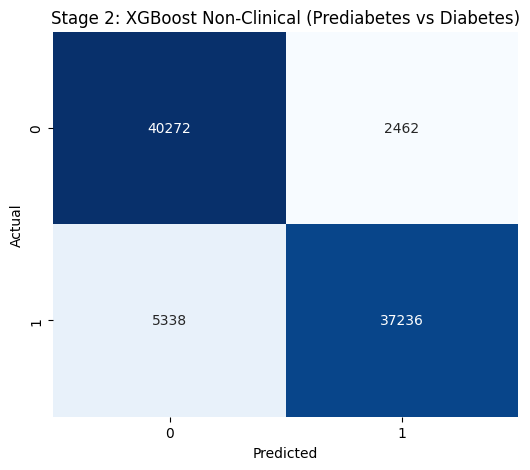

array([0, 0, 1, ..., 0, 1, 1])

In [ ]:
# Evaluate Stage 2 - Non-Clinical
evaluate_binary_model(xgb_stage2_non_clinical, Xn_test_s2, yn_test_s2,
                     "Stage 2: XGBoost Non-Clinical (Prediabetes vs Diabetes)")

In [ ]:
print("TESTING DIFFERENT THRESHOLDS FOR STAGE 2 (CLINICAL)")
print(f"{'Threshold':<12} {'Recall_0':<15} {'Recall_1':<15} {'Precision_1':<15} {'F1_1':<12}")
print("-" * 80)

thresholds_s2 = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

best_balanced_f1 = 0
best_threshold_s2 = 0.5

for threshold in thresholds_s2:
    # Predict on Stage 2 test set with custom threshold
    stage2_proba = xgb_stage2_clinical.predict_proba(Xc_test_s2)[:, 1]
    stage2_pred = (stage2_proba >= threshold).astype(int)
    
    # Calculate metrics
    recall_0 = recall_score(yc_test_s2, stage2_pred, pos_label=0)  # Prediabetes
    recall_1 = recall_score(yc_test_s2, stage2_pred, pos_label=1)  # Diabetes
    precision_1 = precision_score(yc_test_s2, stage2_pred, pos_label=1, zero_division=0)
    f1_0 = f1_score(yc_test_s2, stage2_pred, pos_label=0)
    f1_1 = f1_score(yc_test_s2, stage2_pred, pos_label=1)
    
    # Balanced F1 (average of both classes)
    balanced_f1 = (f1_0 + f1_1) / 2
    
    print(f"{threshold:<12.2f} {recall_0:<15.3f} {recall_1:<15.3f} {precision_1:<15.3f} {f1_1:<12.3f}")
    
    # Track best threshold (balanced performance)
    if balanced_f1 > best_balanced_f1:
        best_balanced_f1 = balanced_f1
        best_threshold_s2 = threshold

print("-" * 80)
print(f"\nRECOMMENDED THRESHOLD: {best_threshold_s2}")
print(f"   Balanced F1 Score: {best_balanced_f1:.3f}")
print("\nNote: Lower threshold = catch more DIABETES cases")
print("      Higher threshold = catch more PREDIABETES cases")

TESTING DIFFERENT THRESHOLDS FOR STAGE 2 (CLINICAL)
Threshold    Recall_0        Recall_1        Precision_1     F1_1        
--------------------------------------------------------------------------------


0.30         0.851           0.973           0.867           0.917       
0.35         0.897           0.962           0.903           0.931       
0.40         0.928           0.947           0.929           0.938       
0.45         0.948           0.929           0.947           0.938       
0.50         0.962           0.908           0.960           0.933       
0.55         0.971           0.883           0.968           0.924       
0.60         0.979           0.853           0.976           0.910       
0.65         0.983           0.817           0.979           0.891       
0.70         0.987           0.775           0.983           0.867       
--------------------------------------------------------------------------------

RECOMMENDED THRESHOLD: 0.45
   Balanced F1 Score: 0.939

Note: Lower threshold = catch more DIABETES cases
      Higher threshold = catch more PREDIABETES cases


### Complete Hierarchical Model Evaluation

In [ ]:
# Recreate full test set with original labels
_, X_test_full_c, _, y_test_full = train_test_split(
    X_clinical, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

_, X_test_full_n, _, _ = train_test_split(
    X_non_clinical, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Full test set shape:", X_test_full_c.shape)
print("Full test labels distribution:")
print(pd.Series(y_test_full).value_counts().sort_index())

Full test set shape: (123319, 30)
Full test labels distribution:
Diabetes_012
0.0    38011
1.0    42734
2.0    42574
Name: count, dtype: int64



*** COMPLETE HIERARCHICAL MODEL (3-CLASS) ***

Using Stage 1 threshold: 0.2
Using Stage 2 threshold: 0.4
Hierarchical XGBoost - Clinical Features
Accuracy: 0.8778
F1-Score (macro): 0.8752
F1-Score (weighted): 0.8773

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.95      0.72      0.82     38011
 Prediabetes       0.97      0.95      0.96     42734
    Diabetes       0.77      0.95      0.85     42574

    accuracy                           0.88    123319
   macro avg       0.89      0.87      0.88    123319
weighted avg       0.89      0.88      0.88    123319



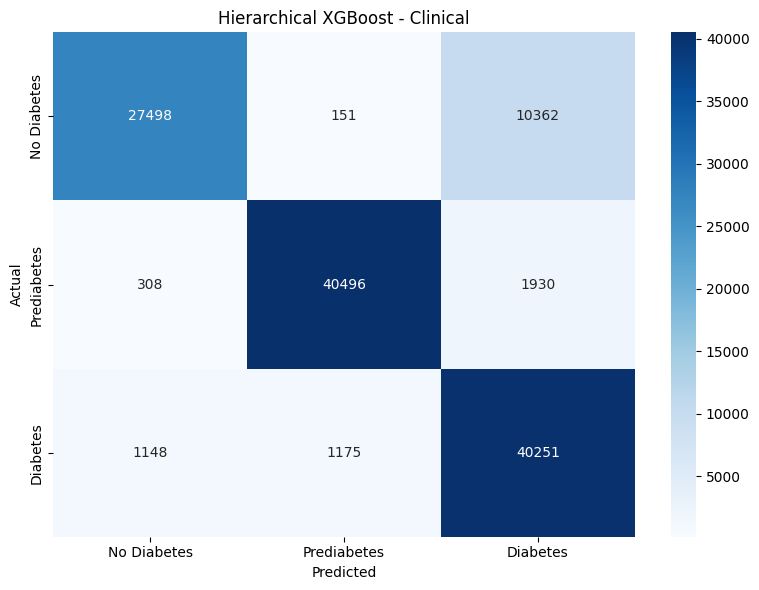

In [ ]:
# Evaluate Hierarchical Model - Clinical with BOTH optimized thresholds
print("\n*** COMPLETE HIERARCHICAL MODEL (3-CLASS) ***\n")

# Set thresholds based on testing results above
OPTIMAL_THRESHOLD_S1 = 0.2   # From Stage 1 threshold testing
OPTIMAL_THRESHOLD_S2 = 0.4   # From Stage 2 threshold testing (ADJUST BASED ON YOUR RESULTS)

# Evaluate with both optimized thresholds
y_pred_hierarchical_c = hierarchical_predict(
    xgb_stage1_clinical, 
    xgb_stage2_clinical,
    X_test_full_c,
    threshold_s1=OPTIMAL_THRESHOLD_S1,
    threshold_s2=OPTIMAL_THRESHOLD_S2
)

print(f"Using Stage 1 threshold: {OPTIMAL_THRESHOLD_S1}")
print(f"Using Stage 2 threshold: {OPTIMAL_THRESHOLD_S2}")
print("=" * 60)
print("Hierarchical XGBoost - Clinical Features")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test_full, y_pred_hierarchical_c):.4f}")
print(f"F1-Score (macro): {f1_score(y_test_full, y_pred_hierarchical_c, average='macro'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test_full, y_pred_hierarchical_c, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_full, y_pred_hierarchical_c, 
                            target_names=['No Diabetes', 'Prediabetes', 'Diabetes']))

# Confusion matrix
cm = confusion_matrix(y_test_full, y_pred_hierarchical_c)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=['No Diabetes', 'Prediabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Prediabetes', 'Diabetes'])
plt.title("Hierarchical XGBoost - Clinical")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
# Detailed per-class metrics
print("\n" + "=" * 60)
print("DETAILED PER-CLASS PERFORMANCE")
print("=" * 60)

for class_idx, class_name in enumerate(['No Diabetes', 'Prediabetes', 'Diabetes']):
    mask = (y_test_full == class_idx)
    pred_mask = (y_pred_hierarchical_c == class_idx)
    
    if mask.sum() > 0:
        recall = recall_score(y_test_full == class_idx, y_pred_hierarchical_c == class_idx)
        precision = precision_score(y_test_full == class_idx, y_pred_hierarchical_c == class_idx, zero_division=0)
        
        print(f"\n{class_name}:")
        print(f"  Total cases: {mask.sum()}")
        print(f"  Correctly classified: {((y_test_full == class_idx) & (y_pred_hierarchical_c == class_idx)).sum()}")
        print(f"  Recall: {recall:}% (of actual cases caught)")
        print(f"  Precision: {precision:}% (of predictions that were correct)")


DETAILED PER-CLASS PERFORMANCE

No Diabetes:
  Total cases: 38011
  Correctly classified: 27498
  Recall: 0.72342216726737% (of actual cases caught)
  Precision: 0.9497133383988395% (of predictions that were correct)

Prediabetes:
  Total cases: 42734
  Correctly classified: 40496
  Recall: 0.9476295221603407% (of actual cases caught)
  Precision: 0.9682941992252881% (of predictions that were correct)

Diabetes:
  Total cases: 42574
  Correctly classified: 40251
  Recall: 0.9454361817071452% (of actual cases caught)
  Precision: 0.7660582760786403% (of predictions that were correct)


Hierarchical XGBoost - Non-Clinical Features
Accuracy: 0.8600
F1-Score (macro): 0.8582
F1-Score (weighted): 0.8586

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.91      0.80      0.85     38011
 Prediabetes       0.87      0.97      0.92     42734
    Diabetes       0.81      0.80      0.81     42574

    accuracy                           0.86    123319
   macro avg       0.86      0.86      0.86    123319
weighted avg       0.86      0.86      0.86    123319



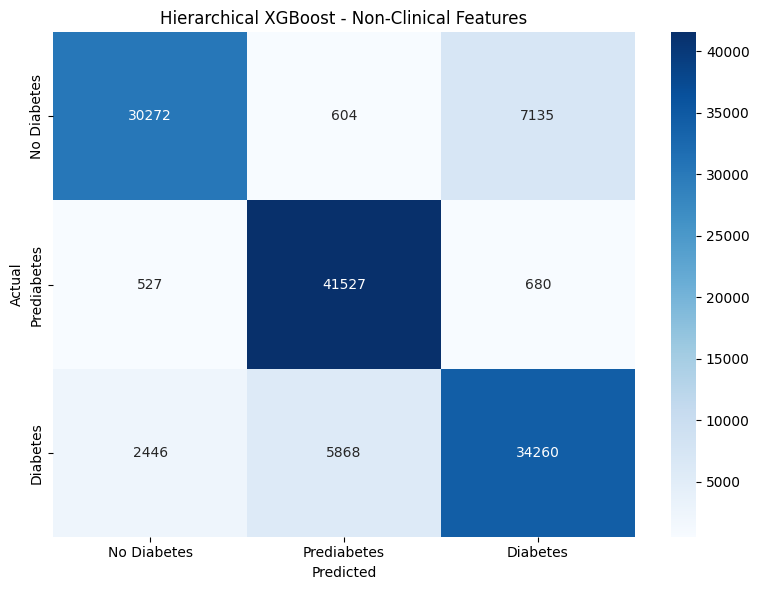

In [ ]:
# Evaluate Hierarchical Model - Non-Clinical
y_pred_hierarchical_n = evaluate_hierarchical_model(
    xgb_stage1_non_clinical,
    xgb_stage2_non_clinical,
    X_test_full_n,
    y_test_full,
    "Hierarchical XGBoost - Non-Clinical Features"
)